In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, 
    RocCurveDisplay, classification_report
)
from sklearn import tree


plt.style.use('seaborn-v0_8-whitegrid')

In [80]:
df = pd.read_csv('Titanic_data.csv', dtype={
    'Name': 'str', 'Sex': 'str'
})

In [81]:
df.shape


(891, 12)

In [82]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [83]:
# Get a feel for missing values and data types
print('Missing values:')
print(df.isnull().sum())

print('\nData types:')
print(df.dtypes)

print('\nBasic stats:')
df.describe()

Missing values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

Basic stats:


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [84]:
# look through the entire name column to find any patterns in the titles and extract them

# Extract Title
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Create FamilySize
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create 'IsAlone' feature
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1

print(df[['Title', 'FamilySize', 'IsAlone']].head())

  Title  FamilySize  IsAlone
0    Mr           2        0
1   Mrs           2        0
2  Miss           1        1
3   Mrs           2        0
4    Mr           1        1


In [85]:


from sklearn.model_selection import cross_val_score

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Comprehensive evaluation report for binary classification.
    """
    # 1. Make Predictions
    y_pred = model.predict(X_test)
    y_probs = model.predict_proba(X_test)[:, 1] # Probability of 'Survived' (class 1)

      # 1. Train vs Test
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test, y_pred)
    print(f"Train Accuracy : {train_acc:.3f}")
    print(f"Test Accuracy  : {test_acc:.3f}")

    # 2. Calculate Metrics
    # Accuracy: Overall percentage of correct predictions
    acc = accuracy_score(y_test, y_pred)
    
    # Precision: Out of all predicted 'Survived', how many actually did? (Reduces False Positives)
    prec = precision_score(y_test, y_pred)
    
    # Recall: Out of all who actually 'Survived', how many did we find? (Reduces False Negatives)
    rec = recall_score(y_test, y_pred)
    
    # F1 Score: The harmonic mean of Precision and Recall (best for balanced evaluation)
    f1 = f1_score(y_test, y_pred)
    
    # ROC-AUC: Ability of the model to distinguish between classes (1.0 is perfect)
    auc = roc_auc_score(y_test, y_probs)
    
    # Cross-Validation: Check stability by testing on 5 different subsets of the data
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    # 3. Print the Easy-to-Read Report
    print(f" {'='*10} {model_name.upper()} EVALUATION REPORT {'='*10} ")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"ROC-AUC:   {auc:.4f}")
    print(f"CV Mean:   {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")
    print("-" * 50)
    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    # 4. Visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Confusion Matrix: Shows True Positives, True Negatives, False Positives, False Negatives
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax1, cmap='Blues')
    ax1.set_title(f"Confusion Matrix: {model_name}")

    # ROC Curve: Visualizes the trade-off between sensitivity and specificity
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax2)
    ax2.set_title(f"ROC Curve: {model_name}")
    ax2.plot([0, 1], [0, 1], 'k--') # Baseline diagonal line

    plt.tight_layout()
    plt.show()

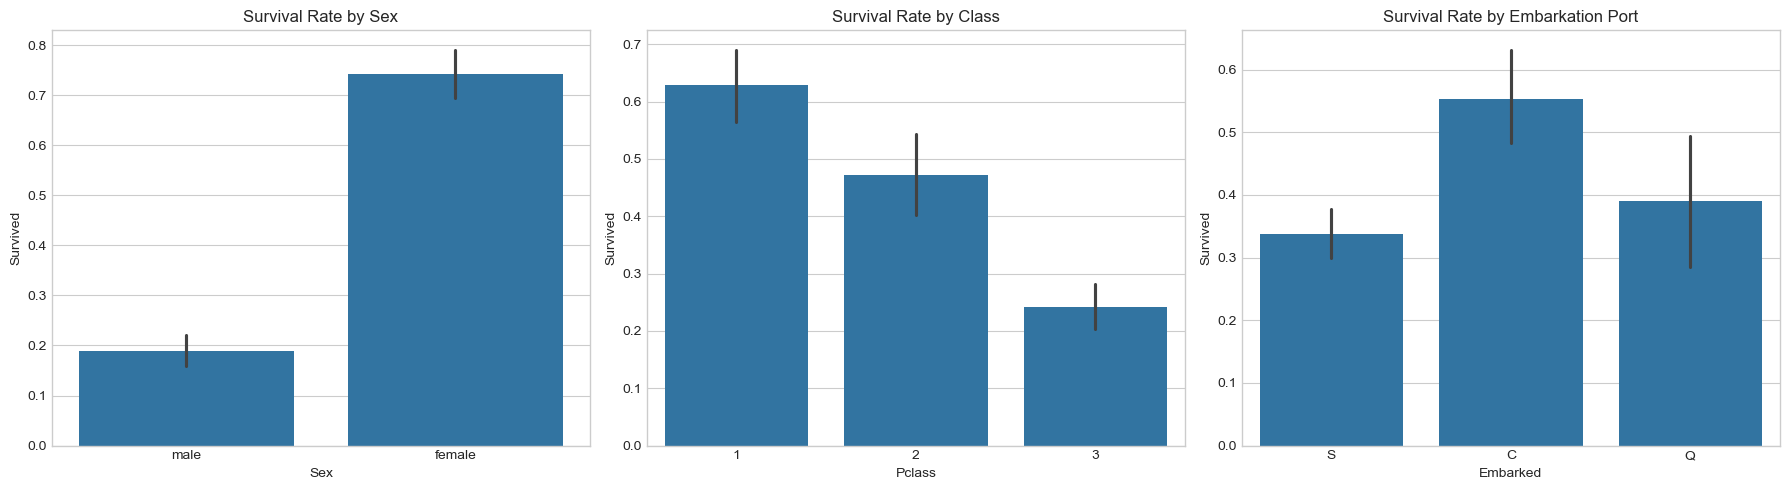

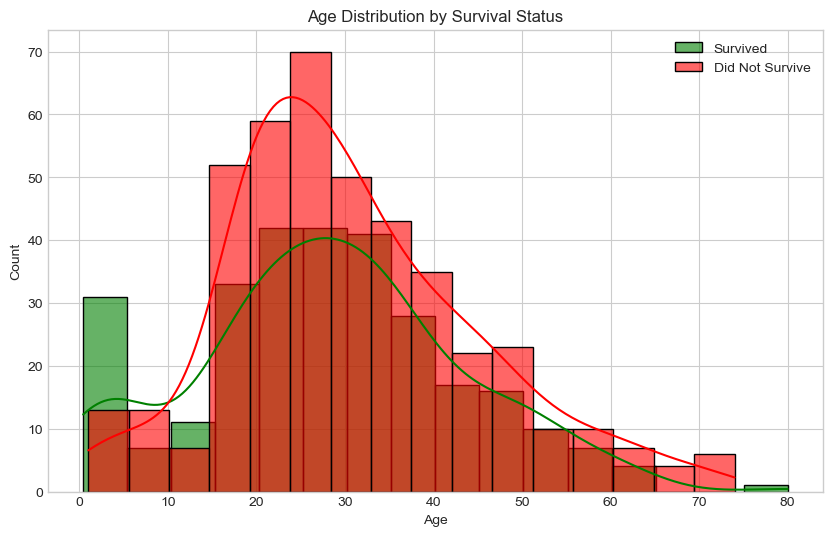

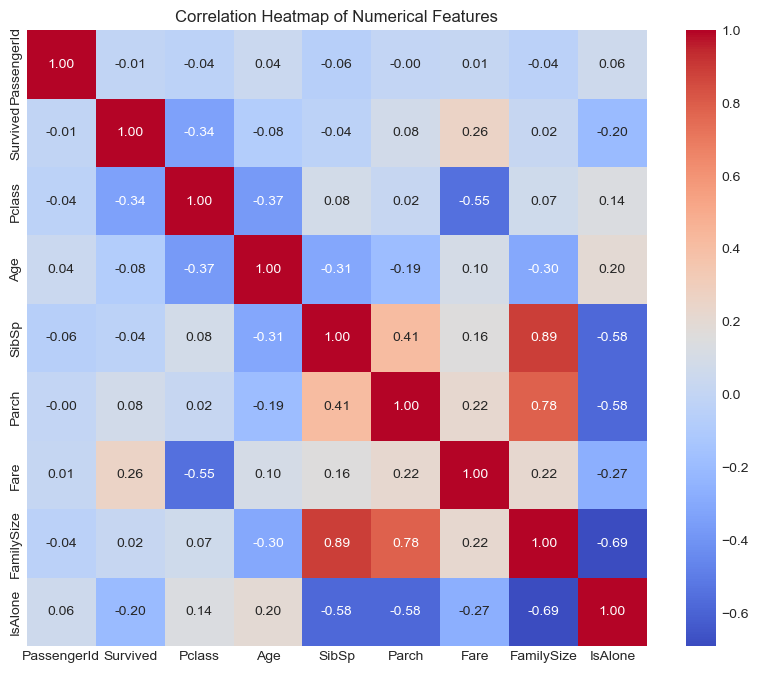

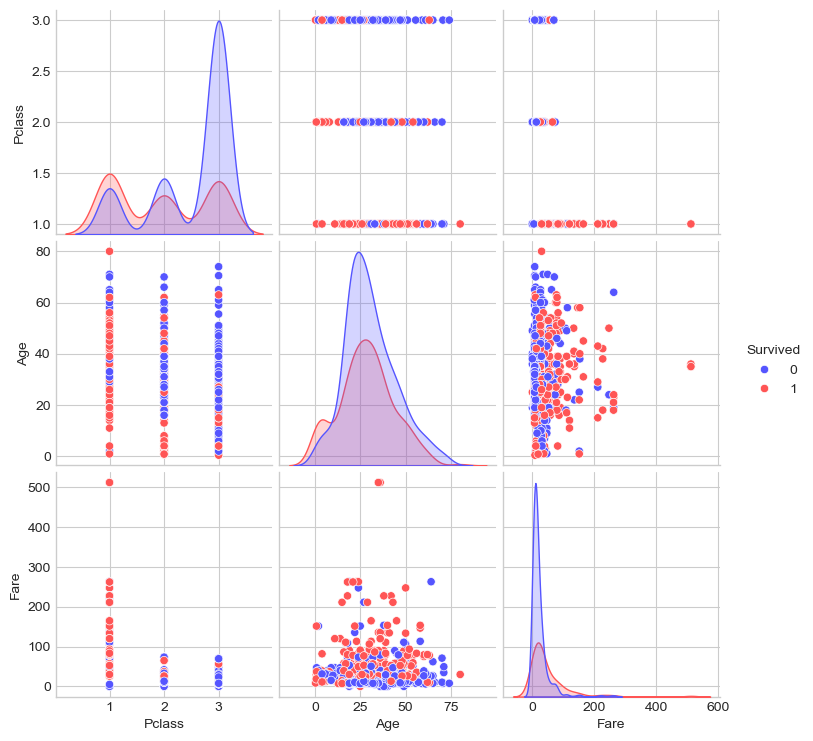

In [86]:

# 1. Survival Distribution by Key Categories
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1])
axes[1].set_title('Survival Rate by Class')

sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2])
axes[2].set_title('Survival Rate by Embarkation Port')

plt.tight_layout()
plt.show()

# 2. Age Distribution: Survived vs Not Survived
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Survived'] == 1]['Age'], kde=True, color='green', label='Survived', alpha=0.6)
sns.histplot(df[df['Survived'] == 0]['Age'], kde=True, color='red', label='Did Not Survive', alpha=0.6)
plt.title('Age Distribution by Survival Status')
plt.legend()
plt.show()

# 3. Correlation Heatmap (Numerical Features)
plt.figure(figsize=(10, 8))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# 4. Pairplot to see multi-variable relationships
sns.pairplot(df[['Survived', 'Pclass', 'Age', 'Fare']], hue='Survived', palette='seismic')
plt.show()

In [87]:
# 1. Define X and y  
cols_to_drop = ['Survived', 'PassengerId', 'Cabin', 'Fare'] # getting rid of unecessary columns (they are noise and dont add useful info)
X = df.drop(columns=cols_to_drop)
y = df['Survived']

In [88]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,1


In [89]:
for col in X.columns:
    print(f"Unique values in column '{col}':")
    print(X[col].unique())
    print("\n")

Unique values in column 'Pclass':
[3 1 2]


Unique values in column 'Name':
['Braund, Mr. Owen Harris'
 'Cumings, Mrs. John Bradley (Florence Briggs Thayer)'
 'Heikkinen, Miss. Laina' 'Futrelle, Mrs. Jacques Heath (Lily May Peel)'
 'Allen, Mr. William Henry' 'Moran, Mr. James' 'McCarthy, Mr. Timothy J'
 'Palsson, Master. Gosta Leonard'
 'Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)'
 'Nasser, Mrs. Nicholas (Adele Achem)' 'Sandstrom, Miss. Marguerite Rut'
 'Bonnell, Miss. Elizabeth' 'Saundercock, Mr. William Henry'
 'Andersson, Mr. Anders Johan' 'Vestrom, Miss. Hulda Amanda Adolfina'
 'Hewlett, Mrs. (Mary D Kingcome) ' 'Rice, Master. Eugene'
 'Williams, Mr. Charles Eugene'
 'Vander Planke, Mrs. Julius (Emelia Maria Vandemoortele)'
 'Masselmani, Mrs. Fatima' 'Fynney, Mr. Joseph J' 'Beesley, Mr. Lawrence'
 'McGowan, Miss. Anna "Annie"' 'Sloper, Mr. William Thompson'
 'Palsson, Miss. Torborg Danira'
 'Asplund, Mrs. Carl Oscar (Selma Augusta Emilia Johansson)'
 'Emir, Mr. Farred Chehab

In [90]:
# make my own bins for age

from sklearn.tree import DecisionTreeClassifier


df['Age_Bins_Custom'] = df['Age'].apply(lambda x: 
    'Infant' if x < 1 else
    'Child' if x < 13 else
    'Teen' if x < 18 else
    'Young Adult' if x < 30 else
    'Adult' if x < 60 else
    'Senior')
X3 = pd.get_dummies(df[['Age_Bins_Custom']], drop_first=True)
score3 = cross_val_score(DecisionTreeClassifier(), X3, y, cv=5).mean()
print(f"Custom bins: {score3:.3f}")

Custom bins: 0.629


In [91]:



# 2. Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Preprocess  
X_train = pd.get_dummies(X_train, dummy_na=True)
X_test  = pd.get_dummies(X_test,  dummy_na=True)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())



### **Decision Tree**
##### A decision tree splits data into branches based on feature values to reach a logical conclusion or classification.
##### It mimics human decision-making by creating a flowchart-like structure of "if-then" rules to predict outcomes.

In [92]:
# Define and fit model
dt_model = tree.DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [93]:
dt_model.score(X_test, y_test)

0.8324022346368715

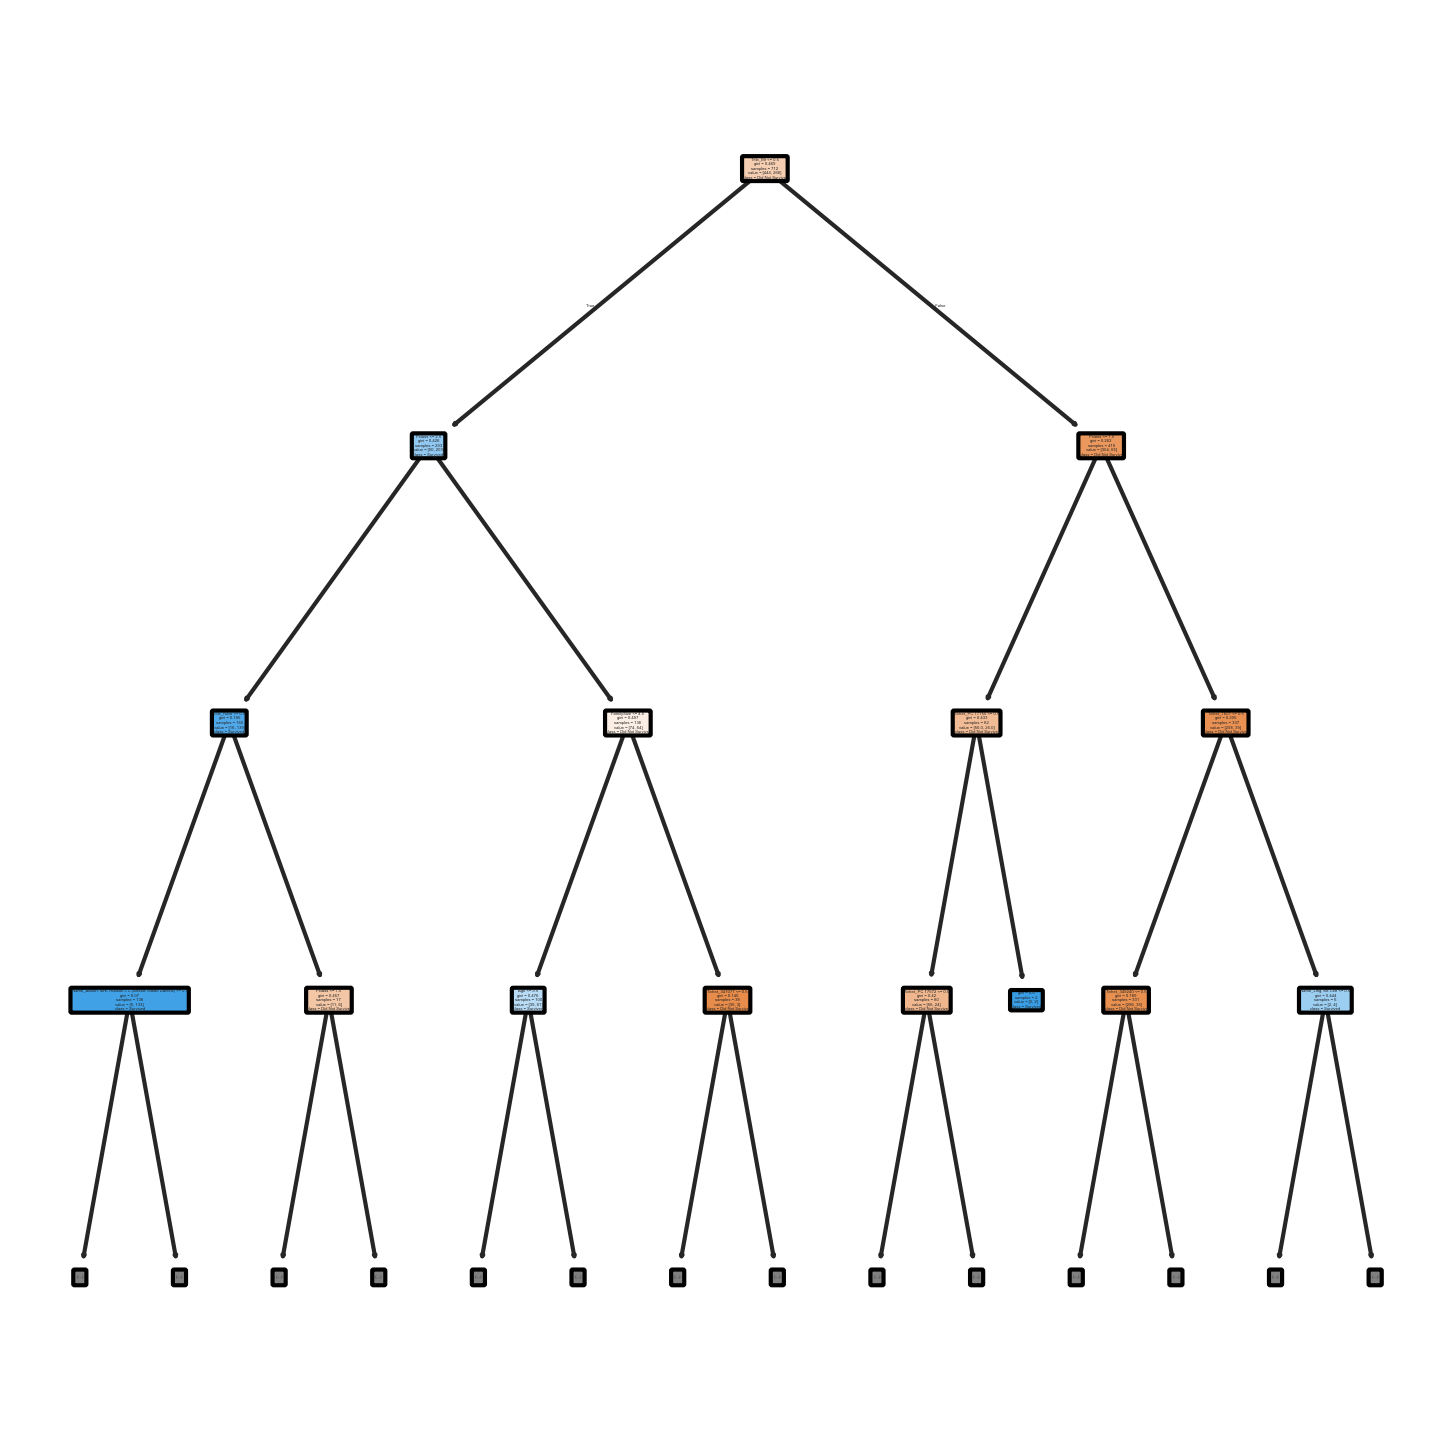

In [94]:
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6, 6), dpi=300)
tree.plot_tree(
    dt_model,
    feature_names=X_train.columns,
    class_names=['Did Not Survive', 'Survived'],
    max_depth=3,
    filled=True,
    rounded=True
)
plt.show()

Train Accuracy : 0.850
Test Accuracy  : 0.832
 ========== DECISION TREE EVALUATION REPORT ========== 
Accuracy:  0.8324
Precision: 0.7973
Recall:    0.7973
F1 Score:  0.7973
ROC-AUC:   0.9035
CV Mean:   0.8174 (+/- 0.0418)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179

--------------------------------------------------


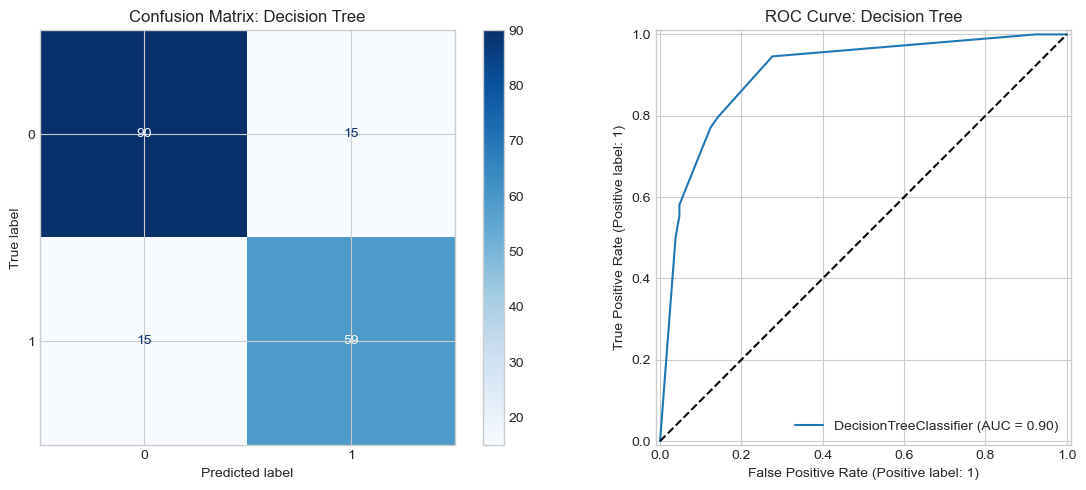

In [95]:
evaluate_model(dt_model, X_train, X_test, y_train, y_test, "Decision Tree")

### **Random Forest**
##### Random Forest is an ensemble of decision trees that averages multiple predictions to improve accuracy and reduce overfitting.
##### It works by training each tree on a random subset of data and features, ensuring a robust and stable final result.

In [96]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,   # number of trees
    max_depth=6,        # max depth of each tree
    random_state=42     # for reproducibility
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [97]:
rf_model.score(X_test, y_test)

0.7932960893854749

Train Accuracy : 0.829
Test Accuracy  : 0.793
 ========== RANDOM FOREST EVALUATION REPORT ========== 
Accuracy:  0.7933
Precision: 0.7846
Recall:    0.6892
F1 Score:  0.7338
ROC-AUC:   0.8699
CV Mean:   0.7949 (+/- 0.0517)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.78      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179

--------------------------------------------------


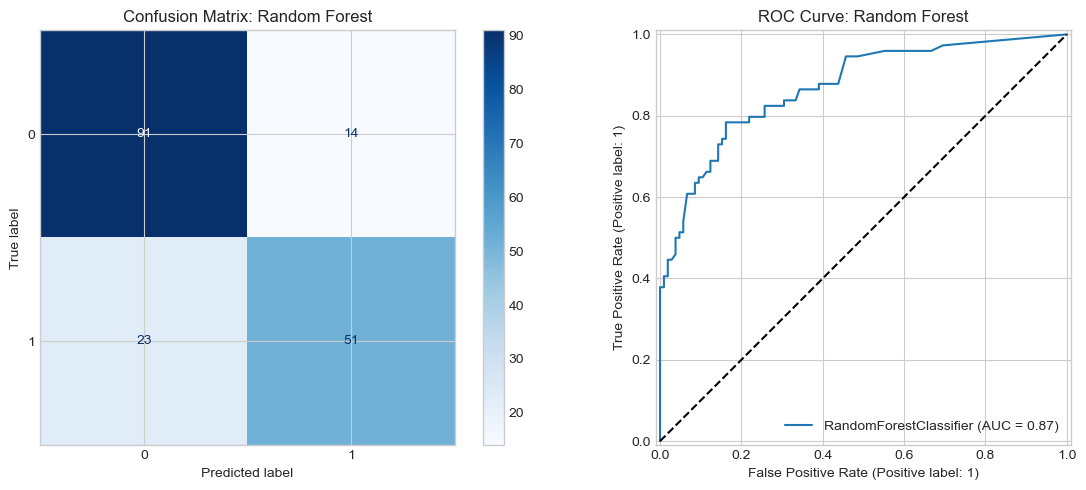

In [98]:
evaluate_model(rf_model, X_train, X_test, y_train, y_test, "Random Forest")

### logistic regression
#####  Logistic regression predicts the probability of a binary outcome (0 or 1) by fitting data to a sigmoid curve.
##### It is used for classification tasks to determine the likelihood of an observation belonging to a specific category.

In [99]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [100]:
lr_model.score(X_test, y_test)

0.8324022346368715

Train Accuracy : 0.919
Test Accuracy  : 0.832
 ========== LOGISTIC REGRESSION EVALUATION REPORT ========== 
Accuracy:  0.8324
Precision: 0.7973
Recall:    0.7973
F1 Score:  0.7973
ROC-AUC:   0.9049
CV Mean:   0.8328 (+/- 0.0427)
--------------------------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       105
           1       0.80      0.80      0.80        74

    accuracy                           0.83       179
   macro avg       0.83      0.83      0.83       179
weighted avg       0.83      0.83      0.83       179

--------------------------------------------------


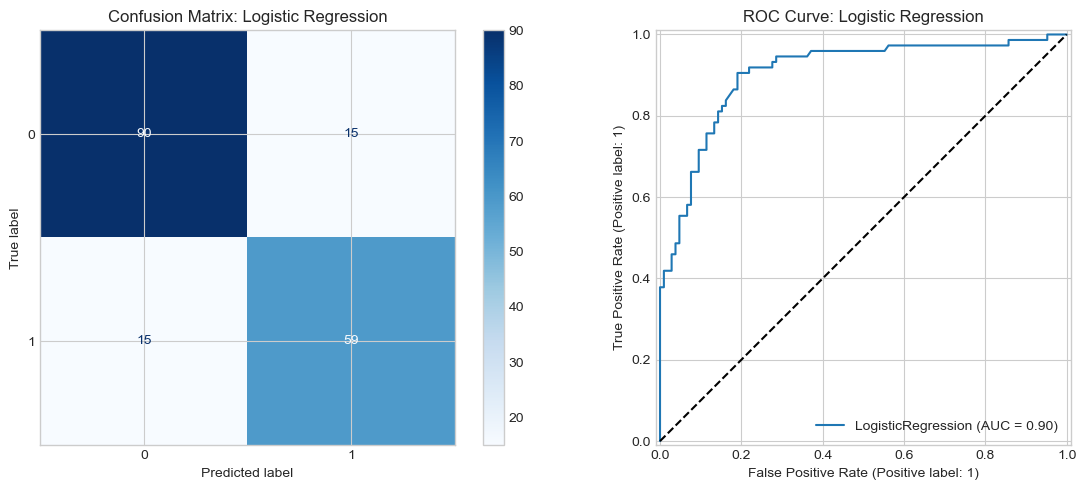

In [101]:
evaluate_model(lr_model, X_train, X_test, y_train, y_test, "Logistic Regression")